# **BÁO CÁO PHÂN TÍCH ĐƠN BIẾN**

## **Phần I: Tổng quan Dữ liệu và Phân loại Biến**
### **1.1. Tải và Tóm tắt bộ dữ liệu**
Bước đầu tiên là khai báo các thư viện cần thiết, tải bộ dữ liệu `train.csv` và xem xét kích thước cũng như cấu trúc cơ bản của dữ liệu.

In [1]:
# Cell gọi dữ liệu
import pandas as pd 
import os
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('Đang khai báo dữ liệu')

# Dữ liệu thô ban đầu
file_path = os.path.join("..", "Data", "train.csv")

df = pd.read_csv(file_path)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print('Khai báo thành công')

print(f"Kích thước bộ dữ liệu: {df.shape[0]} dòng và {df.shape[1]} cột.")

Đang khai báo dữ liệu
Khai báo thành công
Kích thước bộ dữ liệu: 14396 dòng và 18 cột.


### **1.2. Đánh giá Cấu trúc và Kiểu dữ liệu**
Trước khi đi vào vẽ biểu đồ phân tích đơn biến, chúng ta cần dùng hàm `info()` để kiểm tra xem hệ thống (Pandas) đang nhận diện các biến dưới dạng kiểu dữ liệu gì (int, float, object), và có bao nhiêu cột có chứa giá trị Null (thiếu) sơ bộ.

In [2]:
# Xem thông tin cấu trúc cột, kiểu dữ liệu và số lượng non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396 non-null  float64
 16  time

### **1.3. Phân loại Biến**
Dựa trên kiến thức miền về âm thanh và thông tin cấu trúc dữ liệu thu được ở trên, 17 biến độc lập và 1 biến mục tiêu được phân loại thành các nhóm đại số học như sau để phục vụ cho các bước phân tích và tiền xử lý tiếp theo:

**1. Nhóm Biến Định Lượng Liên Tục (Continuous Variables - `float64`):**
* **Danh sách (10 biến):** `danceability`, `energy`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `speechiness`, `loudness`, `tempo`, `duration_in min/ms`.
* *Bản chất:* Nằm trên tập số thực $\mathbb{R}$. Mang ý nghĩa thống kê trực tiếp (có thể tính Mean, Variance, khoảng cách Euclid).
* *Vai trò:* Đây là "linh hồn" của mô hình học máy. Các biến này chứa đựng đặc trưng vật lý của âm thanh.

**2. Nhóm Biến Định Lượng Rời Rạc (Discrete Variables - `float64` / `int64`):**
* **Danh sách (2 biến):** `Popularity` (Độ phổ biến - thang điểm), `time_signature` (Số nhịp).
* *Bản chất:* Mang giá trị số nhưng chỉ nhận các giá trị nguyên tại các điểm rời rạc.

**3. Nhóm Biến Định Tính Danh Nghĩa (Nominal Categorical Variables - `float64` / `int64`):**
* **Danh sách (3 biến):** `key` (Cung/Khóa nhạc: 0-11), `mode` (Thang âm: 0 hoặc 1), `Class` (Biến mục tiêu - Thể loại nhạc).
* *Bản chất:* Dù được mã hóa bằng các con số trong dữ liệu, nhưng về mặt đại số, chúng KHÔNG có tính toán học (khoảng cách giữa khóa 1 và khóa 10 không mang ý nghĩa lớn/nhỏ).

**4. Nhóm Biến Chuỗi/Văn Bản Tự Do (String/Text Variables - `object`):**
* **Danh sách (3 biến):** `Id`, `Artist Name`, `Track Name`.
* *Bản chất:* Dạng chuỗi ký tự định danh định danh độc nhất.
* *Vai trò:* Thường không mang lại giá trị cho các mô hình học máy dạng bảng (Tabular ML) cơ bản như KNN hay Decision Tree mà có thể gây nhiễu, cần xem xét loại bỏ.

## **Phần 2: Phân tích Đơn biến**

Mục tiêu của phần này là quan sát hình dáng phân phối, nhận diện xu hướng trung tâm và độ phân tán của từng biến độc lập. Việc hiểu rõ "tính cách" của từng biến sẽ giúp chúng ta có quyết định chính xác trong bước Tiền xử lý (Preprocessing).

### **2.1. Nhóm Biến Định Lượng Liên Tục**
Chúng ta sẽ sử dụng sự kết hợp giữa *Histogram (Biểu đồ tần suất)* được phủ thêm đường *KDE (Kernel Density Estimate - Ước lượng mật độ hạt nhân)* để xem xét hình dáng phân phối, và *Boxplot (Biểu đồ hộp)* để phát hiện nhanh các giá trị ngoại lai.

Do số lượng biến liên tục khá nhiều (10 biến), ta sẽ chia thành hai nhóm nhỏ để dễ quan sát.

#### **Nhóm 2.1.A: Các đặc trưng âm thanh cốt lõi (Danceability, Energy, Loudness, Tempo)**

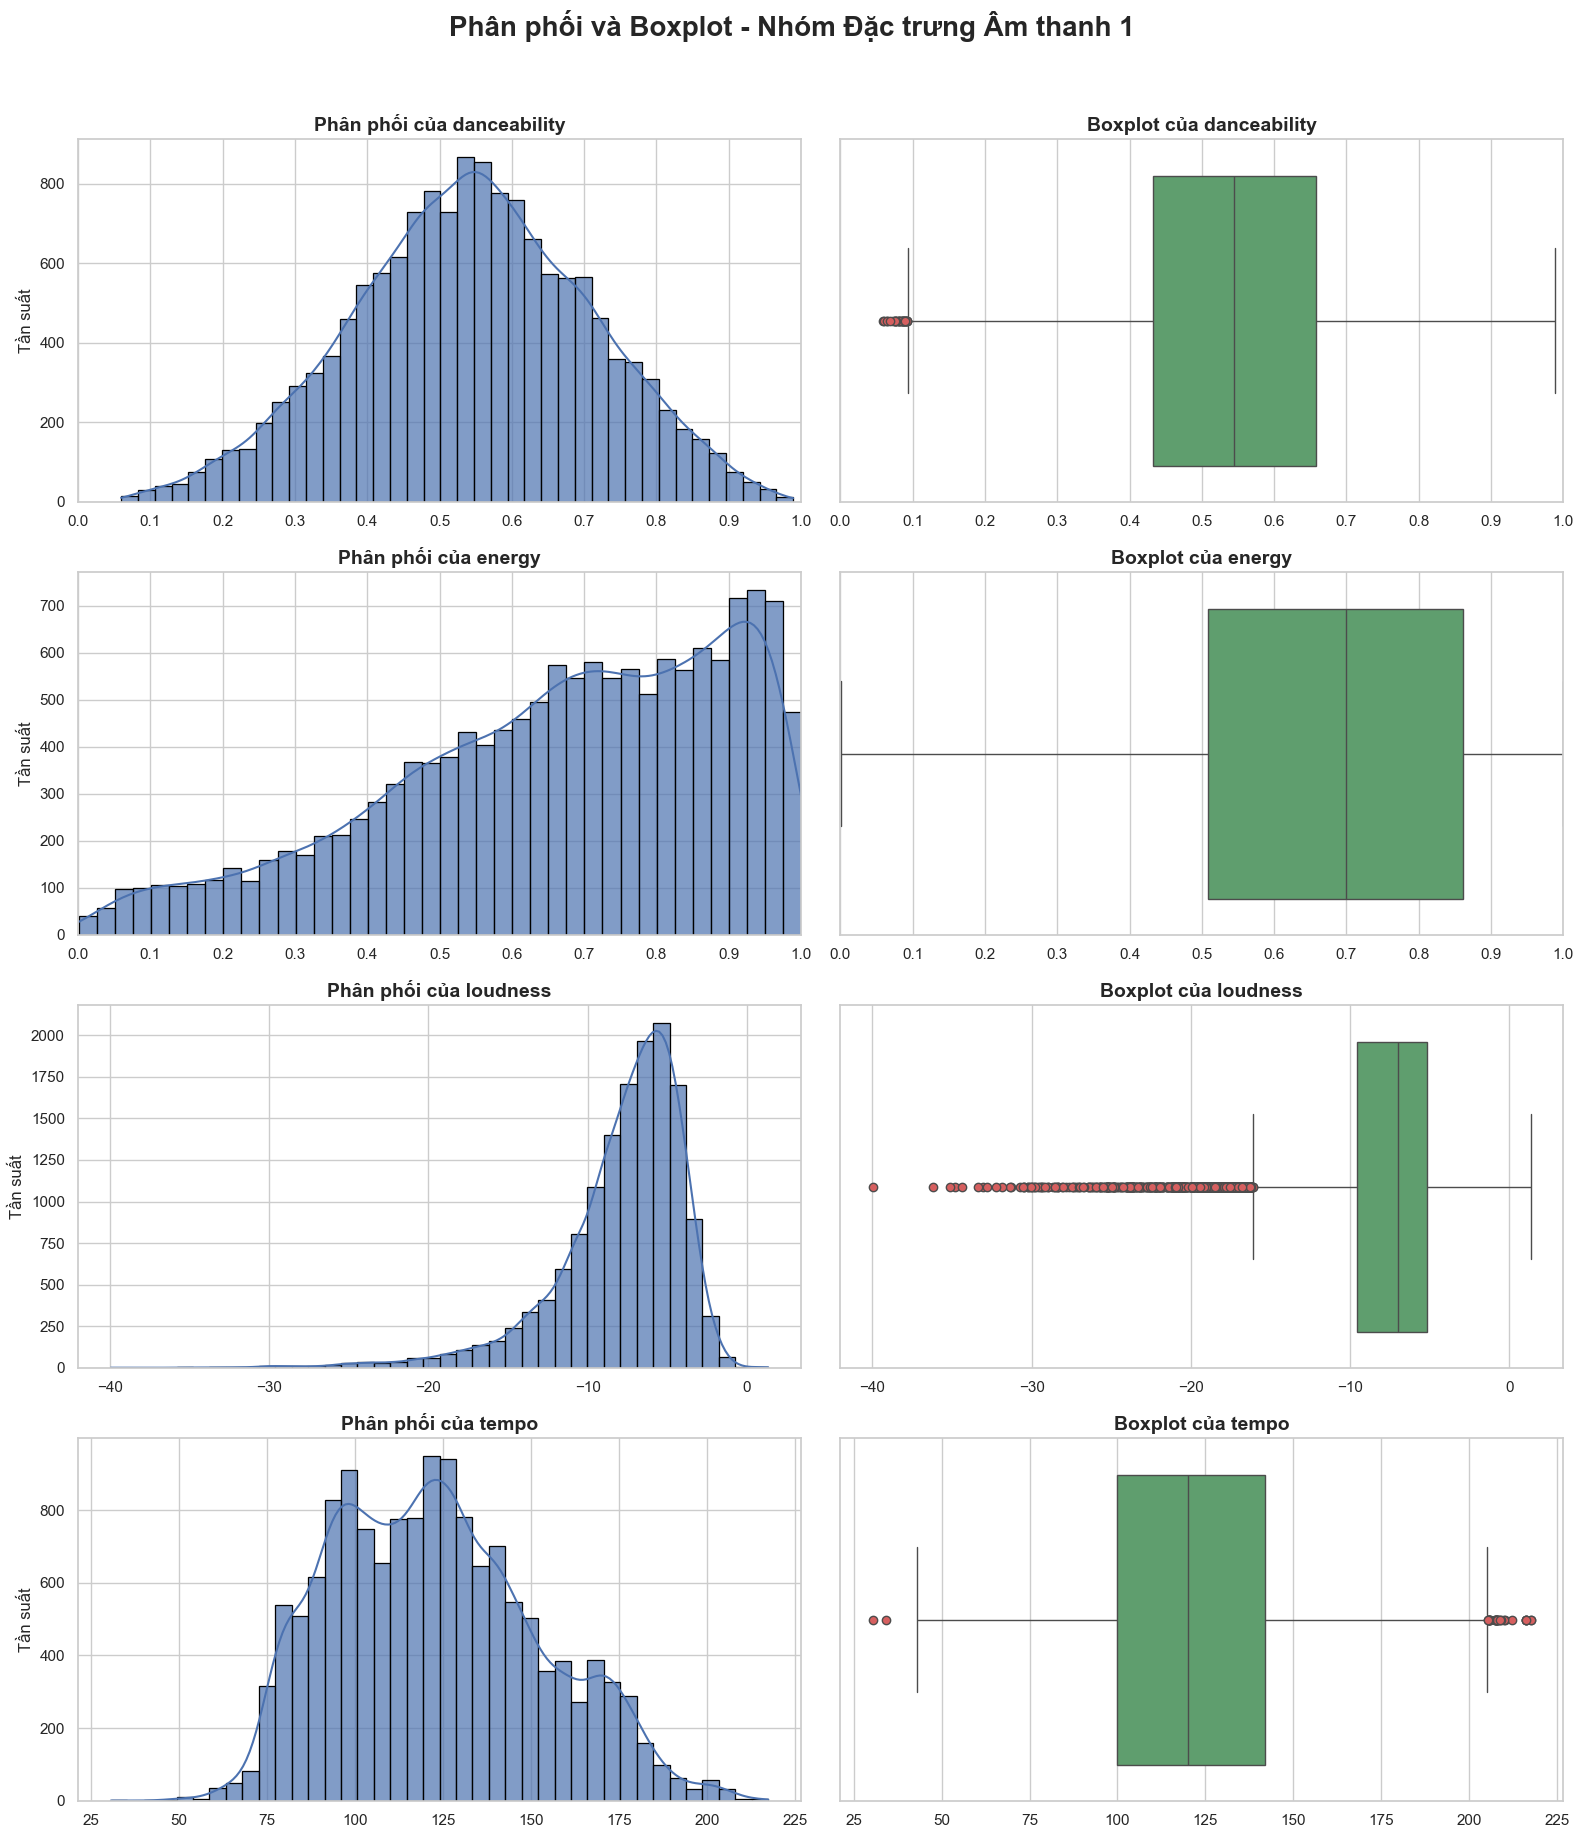

In [12]:
import numpy as np # Thêm thư viện này nếu ở trên bạn chưa import

# Cài đặt lại kích thước font chữ cho dễ nhìn
plt.rcParams.update({'font.size': 12})

# Nhóm các biến liên tục quan trọng đầu tiên
cont_vars_group1 = ['danceability', 'energy', 'loudness', 'tempo']

# Tạo một lưới biểu đồ (grid) 4 hàng x 2 cột
fig, axes = plt.subplots(nrows=len(cont_vars_group1), ncols=2, figsize=(16, 18))
fig.suptitle('Phân phối và Boxplot - Nhóm Đặc trưng Âm thanh 1', fontsize=20, fontweight='bold', y=1.02)

for i, col in enumerate(cont_vars_group1):
    # Cột 1: Histogram + KDE
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color='#4C72B0', bins=40, edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'Phân phối của {col}', fontsize=14, fontweight='bold')
    axes[i, 0].set_ylabel('Tần suất')
    axes[i, 0].set_xlabel('')

    # Cột 2: Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='#55A868', flierprops=dict(markerfacecolor='r', marker='o'))
    axes[i, 1].set_title(f'Boxplot của {col}', fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel('')

    # -------------------------------------------------------------
    # TÙY CHỈNH LƯỚI TRỤC HOÀNH (Chỉ áp dụng cho biến có dải 0 -> 1)
    # -------------------------------------------------------------
    if col in ['danceability', 'energy']:
        # Tạo mảng tick từ 0.0 đến 1.0 với bước nhảy 0.1
        ticks = np.arange(0, 1.1, 0.1)
        
        # Áp dụng cho cả biểu đồ Histogram (cột 0) và Boxplot (cột 1)
        axes[i, 0].set_xticks(ticks)
        axes[i, 1].set_xticks(ticks)
        
        # Khóa cứng giới hạn hiển thị từ 0 đến 1 cho đẹp
        axes[i, 0].set_xlim(0, 1)
        axes[i, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

Dựa trên biểu đồ Histogram kết hợp đường cong KDE và Boxplot, chúng ta có thể rút ra những đặc tính thống kê và nguyên nhân sâu xa của từng biến như sau:

**Biến `danceability` (Độ nhịp nhàng / Khả năng khiêu vũ)**
* **Quan sát phân phối**: Phân phối có dạng gần chuẩn (Normal-like), hơi lệch trái một chút. Hầu hết dữ liệu tập trung ở nửa phải của biểu đồ, với đỉnh cao nhất nằm ở khoảng 0.5 đến 0.6.
* **Phân tích dị biệt**: Boxplot rất "sạch" và cân đối. Hộp tứ phân vị nằm gọn gàng ở giữa và chỉ xuất hiện một vài điểm dị biệt (outliers) nhỏ lẻ nằm tít ở đáy (các giá trị rất nhỏ, dưới 0.1).
* **Dự đoán nguyên nhân**: Âm nhạc hiện đại chúng đa phần đều có nhịp điệu rõ ràng, dễ nghe, dễ nhún nhảy, giải thích vì sao đỉnh phân phối lại hội tụ ở mức cao. Các điểm outlier xấp xỉ 0 rất có thể là các bản nhạc đặc thù không có nhịp điệu hoặc bộ gõ (ví dụ: nhạc Ambient, âm thanh môi trường/tiếng ồn trắng, thơ ca đọc trên nền nhạc, hoặc nhạc giao hưởng).
* **Đề xuất**: Biến này cực kỳ lý tưởng và hoàn hảo cho việc huấn luyện. Không cần can thiệp hay xóa bỏ outlier, cứ giữ nguyên để mô hình học được cách phân biệt các thể loại "không nhịp điệu" (như Class 0 hoặc Class 3).

**Biến `energy` (Năng lượng)**
* **Quan sát phân phối:** Phân phối lệch trái rõ rệt (Left-skewed). Phần lớn bài hát trong tập dữ liệu đều mang năng lượng từ trung bình khá đến rất cao (tập trung dày đặc ở dải 0.6 đến 0.9). 
* **Phân tích dị biệt:** Boxplot kéo dài phần râu (whisker) dưới nhưng gần như KHÔNG CÓ điểm dị biệt nào vượt ra ngoài ranh giới toán học của Boxplot. 
* **Dự đoán nguyên nhân:** Bộ dữ liệu này có vẻ bị chi phối mạnh bởi các thể loại nhạc hiện đại, ồn ào và dồn dập (Rock, Metal, EDM, Pop). Dải năng lượng thấp (< 0.3) kéo dài thoai thoải cho thấy vẫn có sự hiện diện của nhạc Acoustic, Ballad nhẹ nhàng nhưng số lượng không áp đảo.
* **Đề xuất:** Phân phối lệch không phải là vấn đề quá lớn với Tree-based models (như Decision Tree), nhưng nếu dùng Naive Bayes (giả định phân phối chuẩn), ta có thể cân nhắc biến đổi Box-Cox. Tuy nhiên, tạm thời cứ giữ nguyên vì dữ liệu nằm gọn trong thang [0,1].

**Biến `loudness` (Độ lớn âm thanh / Âm lượng)**
* **Quan sát phân phối:** Cực kỳ lệch trái. Có một "bức tường vô hình" ở mốc 0 dB (âm lượng tối đa của kỹ thuật số không bị méo tiếng). Đỉnh phân phối nhọn hoắt ở khoảng -5 dB.
* **Phân tích dị biệt:** Boxplot cho thấy râu dưới bị cắt xén ở khoảng -17 dB, và để lại một "vệt đỏ" các điểm outlier kéo dài miên man xuống tận -40 dB.
* **Dự đoán nguyên nhân:** Trong ngành công nghiệp âm nhạc, hiện tượng "Loudness War" (Cuộc chiến âm lượng) khiến các bản nhạc Pop/Rock/EDM hiện đại đều bị nén (compress) để đạt mức âm lượng trung bình rất to (quanh -5 dB). Các điểm outlier sâu (- 17dB đến -40 dB) hoàn toàn không phải là dữ liệu lỗi. Đó chính là đặc trưng "sống còn" của nhạc Cổ điển (Classical) hoặc Jazz cổ - những thể loại tôn trọng dải động học với những đoạn chơi cực kỳ nhỏ.
* **Đề xuất:** *Tuyệt đối KHÔNG XÓA các outlier này*, nếu xóa mô hình sẽ "mù" trong việc nhận diện nhạc cổ điển. Tuy nhiên, vì thang đo của `loudness` là số âm và trải dài tới -40, ta *bắt buộc phải chạy Standard Scaler / Min-Max Scaler* trước khi đưa vào mô hình KNN để tránh biến này lấn át khoảng cách của các biến [0,1] khác.

**Biến `tempo` (Nhịp độ / Số nhịp mỗi phút)**
* **Quan sát phân phối:** Phân phối có dạng hình chuông, nhưng hơi bè ra (hoặc có hiện tượng đa đỉnh nhẹ - Bimodal). Đỉnh cao nhất tập trung rất mạnh ở dải 120 - 130 BPM.
* **Phân tích dị biệt:** Xuất hiện outlier ở cả hai đầu (rất chậm < 50 BPM và rất nhanh > 200 BPM). Đặc biệt, cần chú ý có một vài điểm outlier nằm ngay tại mốc *0 BPM*.
* **Dự đoán nguyên nhân:** Mốc 120-128 BPM chính là "tiêu chuẩn vàng" của nhạc Dance và Pop hiện đại, giải thích cho cái đỉnh cao ngất ngưởng kia. Các bài >190 BPM có thể là Speed Metal, Punk, hoặc Drum & Bass.
* **Đề xuất:**
     * *Xử lý lỗi logic:* Một bài hát không thể có Tempo = 0 (trừ khi nó là một khoảng lặng hoàn toàn dài mấy phút). Cần truy xuất các dòng có `tempo == 0`, nếu là lỗi thu thập dữ liệu, cần gán thành giá trị thiếu (NaN) và điền khuyết (Imputation) bằng giá trị Median của Class đó.
    * *Chuẩn hóa:* Tương tự `loudness`, giá trị của `tempo` lên tới ~200, bắt buộc phải Scale cùng với các biến khác.

#### **Nhóm 2.1.B: Các đặc trưng âm thanh phụ và Bối cảnh (Acousticness, Instrumentalness, Liveness, Valence, Speechiness, Duration)**

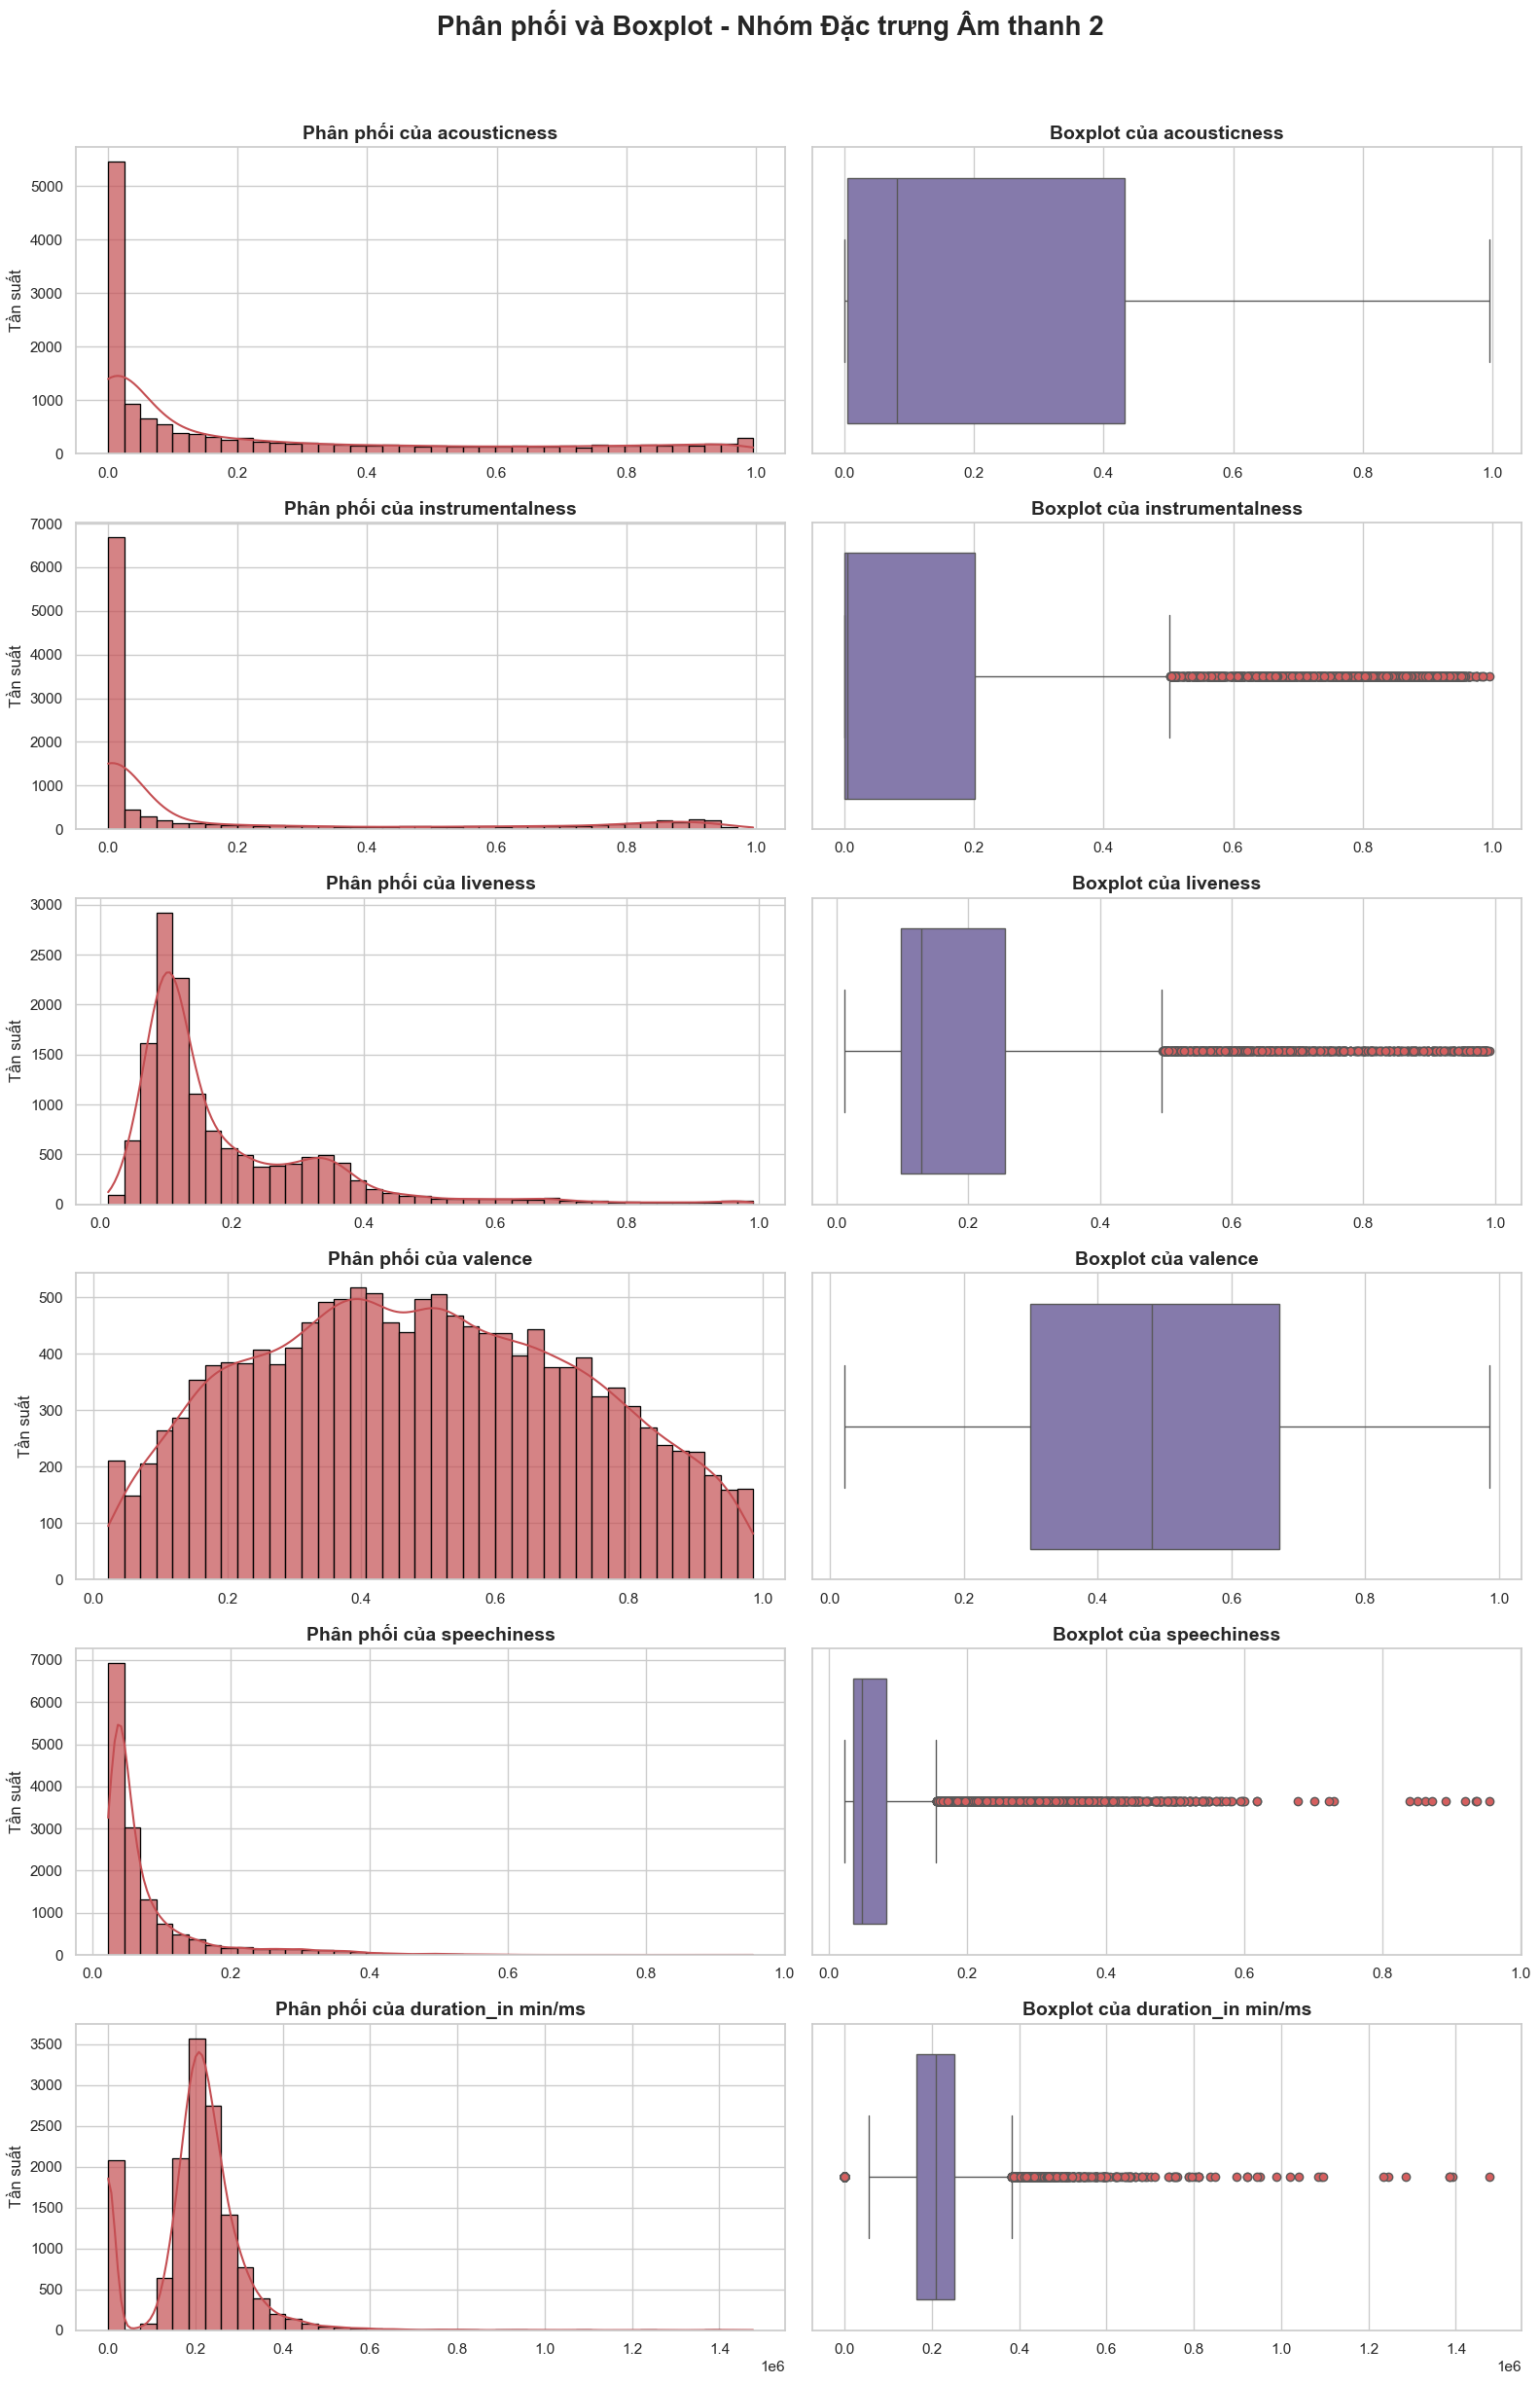

In [4]:
# Nhóm các biến liên tục còn lại
cont_vars_group2 = ['acousticness', 'instrumentalness', 'liveness', 'valence', 'speechiness', 'duration_in min/ms']

fig, axes = plt.subplots(nrows=len(cont_vars_group2), ncols=2, figsize=(16, 24))
fig.suptitle('Phân phối và Boxplot - Nhóm Đặc trưng Âm thanh 2', fontsize=20, fontweight='bold', y=1.02)

for i, col in enumerate(cont_vars_group2):
    # Cột 1: Histogram + KDE
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color='#C44E52', bins=40, edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'Phân phối của {col}', fontsize=14, fontweight='bold')
    axes[i, 0].set_ylabel('Tần suất')
    axes[i, 0].set_xlabel('')

    # Cột 2: Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='#8172B3', flierprops=dict(markerfacecolor='r', marker='o'))
    axes[i, 1].set_title(f'Boxplot của {col}', fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

Nhóm biến này chứa nhiều "cái bẫy" thống kê nhất (đặc biệt là hiện tượng Zero-inflated - dồn ứ tại 0). Việc hiểu sai nhóm này sẽ dẫn đến những sai lầm thảm họa khi tiền xử lý dữ liệu.

**5. Biến `acousticness` (Độ âm thanh mộc / Không dùng nhạc cụ điện tử)**
* **Quan sát phân phối:** Phân phối lệch phải cực mạnh (Right-skewed) hoặc có dạng phân phối hàm mũ. Đỉnh cao nhất tập trung ngay tại mốc 0.0 - 0.1.
* **Phân tích dị biệt:** Dù lệch phải, Boxplot lại không hiển thị nhiều outlier do dữ liệu vẫn nằm đều trong khoảng từ 0 đến 1. Tuy nhiên, dải phân vị (IQR) bị bóp nghẹt ở nửa dưới.
* **Dự đoán nguyên nhân:** Điều này phản ánh chính xác lịch sử âm nhạc hiện đại. Hầu hết các bài hát từ sau thập niên 1980 đều sử dụng guitar điện, synthesizer, hoặc beat máy tính (Acousticness rất thấp). Chỉ có một nhóm nhỏ nhạc Cổ điển, Folk, hoặc Acoustic Ballad thuần túy mới có giá trị tiệm cận 1.
* **Đề xuất:** Giữ nguyên. Cực kỳ hữu ích để nhận diện Class Cổ điển (Classical) hoặc Đồng quê (Country).

**6. Biến `instrumentalness` (Nhạc không lời)**
* **Quan sát phân phối:** *Hiện tượng Zero-inflated (Dồn ứ tại 0).* Hơn 80-90% dữ liệu có giá trị xấp xỉ 0.0. 
* **Phân tích dị biệt:** Boxplot biến thành một đường bẹp dúm ở đáy, và kéo theo đó là một "trận mưa sao băng" các điểm outlier trải dài từ 0.5 đến 1.0.
* **Dự đoán nguyên nhân:** Đây không phải là nhiễu! Hầu hết nhạc đại chúng (Pop, Rock, Rap) đều PHẢI có người hát. Những điểm đỏ outlier kia đại diện cho các bản nhạc giao hưởng, các đoạn beat EDM dài, nhạc Lofi hoặc Jazz thuần nhạc cụ. 
* **Đề xuất:** *Tuyệt đối KHÔNG loại bỏ Outlier.* Tuy nhiên, với các mô hình nhạy cảm với phân phối như Naive Bayes, biến này có thể gây hỏng giả định phân phối chuẩn. *Hướng giải quyết:* Có thể đề xuất tạo thêm một biến nhị phân mới (Feature Engineering): `is_instrumental` (1 nếu > 0.5, 0 nếu ngược lại) để mô hình dễ học hơn.

**7. Biến `valence` (Độ tích cực / Cảm xúc)**
* **Quan sát phân phối:** Phân phối gần như trải đều trên toàn bộ dải [0, 1] với một chút nhấp nhô. Không có sự dồn ứ dữ liệu về một cực nào.
* **Phân tích dị biệt:** Hoàn toàn "sạch sẽ". Boxplot cân đối, không có bất kỳ điểm outlier nào.
* **Dự đoán nguyên nhân:** Âm nhạc phản ánh đủ mọi cung bậc cảm xúc của con người. Từ những bản tình ca u sầu (valence < 0.3) cho đến những bản Reggae/Latin nhảy múa tiệc tùng (valence > 0.8), tất cả đều có đại diện đồng đều trong bộ dữ liệu.
* **Đề xuất:** Biến lý tưởng nhất bộ dữ liệu. Giữ nguyên không cần can thiệp. Rất có giá trị để phân tách các Class mang sắc thái cảm xúc đặc trưng (ví dụ: Blues buồn vs. Pop vui nhộn).

**8. Biến `speechiness` (Tỉ lệ từ ngữ)**
* **Quan sát phân phối:** Lệch phải mạnh. Tập trung cao độ ở mốc 0.00 - 0.05.
* **Phân tích dị biệt:** Boxplot đánh dấu mọi giá trị > 0.18 là outlier.
* **Dự đoán nguyên nhân:** Mốc < 0.1 là mức độ "hát" thông thường (giai điệu lấn át lời). Các mức > 0.18 là các bài đọc rap dồn dập, và > 0.6 có thể là Talkshow hoặc Podcast.
* **Đề xuất:** Các outlier > 0.3 chính là "dấu vân tay" của thể loại Hip-hop / Rap. Cần giữ nguyên. Cân nhắc dùng Log-transform: $log(x + 1)$ để giảm độ lệch phải nếu dùng mô hình hồi quy.

**9. Biến `liveness` (Độ biểu diễn trực tiếp / Hát Live)**
* **Quan sát phân phối:** Phân phối tập trung quanh mức 0.1.
* **Phân tích dị biệt:** Rất nhiều điểm outlier lớn hơn 0.4.
* **Dự đoán nguyên nhân:** Các hãng đĩa thường phát hành bản Studio (thu âm phòng thu, triệt tiêu tiếng ồn khán giả). Chỉ những bản ghi âm từ Concert (Live show) mới có `liveness` cao (có tiếng vỗ tay, tiếng vọng). 
* **Đề xuất:** Biến này ít có ý nghĩa phân loại Thể loại nhạc (vì thể loại nào cũng có thể hát live). Tuy nhiên, không nên xóa vì biết đâu một Class cụ thể (như Rock) lại có tỉ lệ thu âm live cao hơn. 

**10. Biến `duration_in min/ms` (Thời lượng bài hát) - LỖI LOGIC DỮ LIỆU**
* **Quan sát phân phối & Dị biệt:** Có một dải dữ liệu phân bố ở mức hàng trăm nghìn (ví dụ: 180,000 đến 300,000), nhưng lác đác xuất hiện các điểm cực kỳ nhỏ (nhỏ hơn 10).
* **Dự đoán nguyên nhân:** Nhìn ngay vào tên cột `min/ms` (Phút / Mili-giây), ta bắt được ngay một lỗi thu thập dữ liệu kinh điển: *Trộn lẫn đơn vị tính*. Có người nhập 3.5 (nghĩa là 3.5 phút), có người nhập 210000 (nghĩa là 210,000 ms ~ 3.5 phút).
* **Đề xuất:** *BẮT BUỘC PHẢI TIỀN XỬ LÝ.* Phải viết một hàm điều kiện: Nếu giá trị < 100 (khả năng cao là Phút), thì đem nhân với 60,000 để quy đổi toàn bộ về Mili-giây (ms). Sau đó chạy Standard Scaler vì giá trị của biến này là quá khổng lồ so với các biến [0, 1] khác.

### **2.2. Nhóm Biến Phân Loại & Rời Rạc**
Tiếp theo, ta dùng Countplot (Biểu đồ đếm) để kiểm tra tần suất của các giá trị Rời rạc.

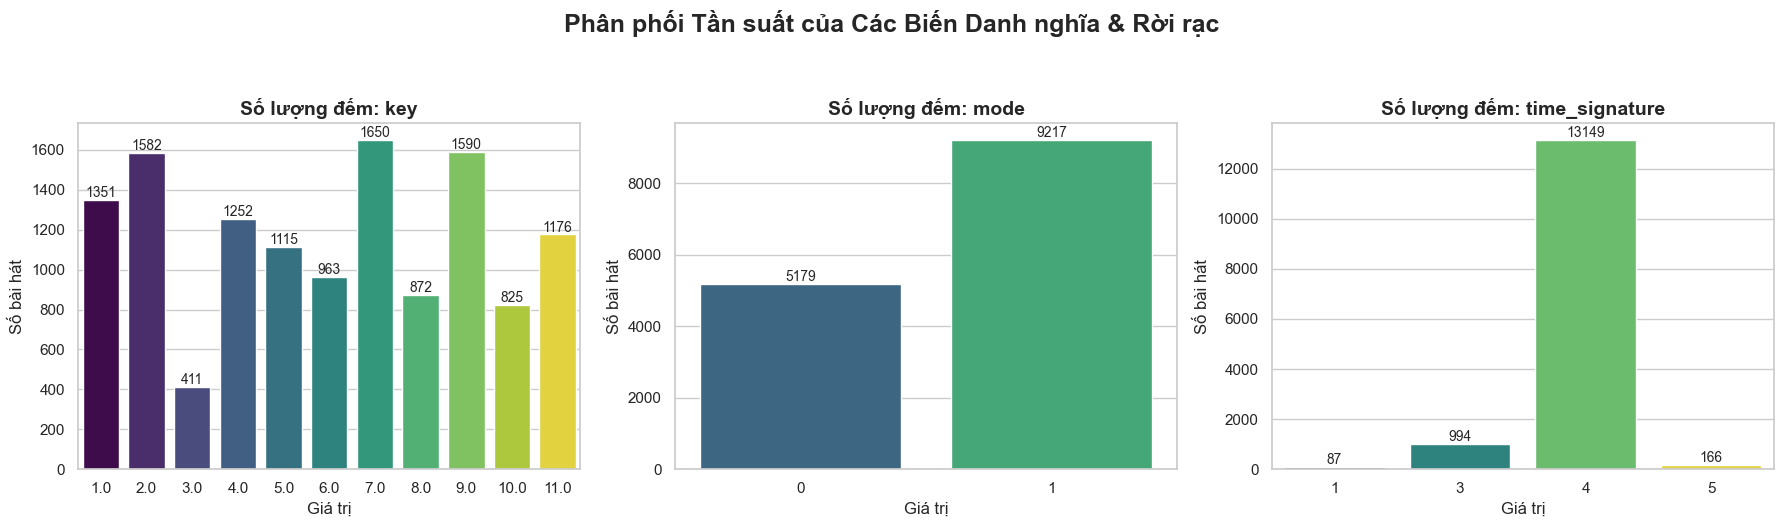

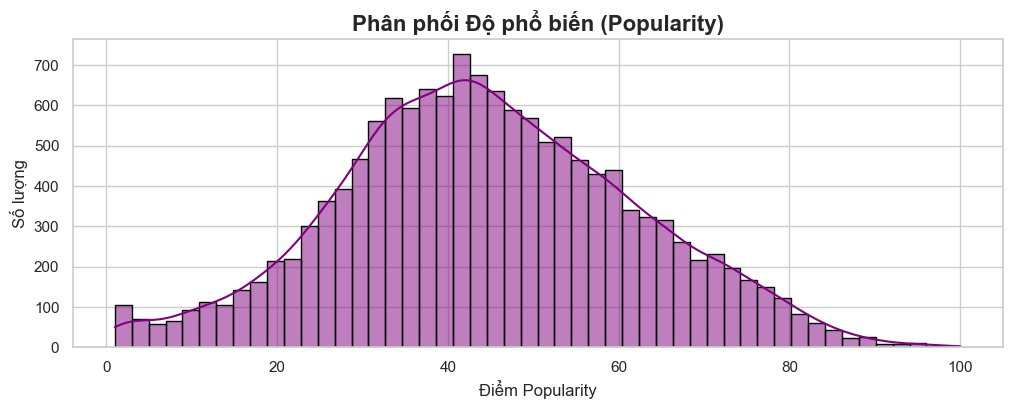

In [5]:
cat_vars = ['key', 'mode', 'time_signature']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân phối Tần suất của Các Biến Danh nghĩa & Rời rạc', fontsize=18, fontweight='bold', y=1.05)

# Cài đặt màu sắc đa dạng
palette_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD']

for i, col in enumerate(cat_vars):
    # Đã sửa lỗi warning bằng cách thêm hue=col và legend=False
    ax = sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette='viridis', legend=False)
    
    axes[i].set_title(f'Số lượng đếm: {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Số bài hát')
    axes[i].set_xlabel('Giá trị')
    
    # Thêm số lượng trực tiếp lên đầu cột
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points', fontsize=10)

plt.tight_layout()
plt.show()

# Biểu đồ riêng cho Popularity
plt.figure(figsize=(12, 4))
sns.histplot(df['Popularity'].dropna(), bins=50, kde=True, color='purple', edgecolor='black')
plt.title('Phân phối Độ phổ biến (Popularity)', fontsize=16, fontweight='bold')
plt.xlabel('Điểm Popularity')
plt.ylabel('Số lượng')
plt.show()

**1. Biến `time_signature` (Số nhịp / Chỉ số thời gian)**
* **Quan sát:** Có đến >90% bài hát mang giá trị 4 (nhịp 4/4). 
* **Dự đoán nguyên nhân:** Nhịp 4/4 là nhịp xương sống của toàn bộ ngành công nghiệp âm nhạc hiện đại phương Tây (từ Pop, Rock đến EDM). Các nhịp 3/4 (nhịp Valse) hay 5/4, 7/8 (nhịp bất đối xứng) rất hiếm, thường chỉ có ở Jazz hoặc Classical.
* **Đề xuất:** Biến này mắc hội chứng *Low Variance (Độ biến thiên quá thấp)*. Nếu đưa vào mô hình, nó gần như là một hằng số và không giúp phân loại được nhiều. *Đề xuất thử nghiệm:* Thử huấn luyện mô hình có và không có biến này để xem có cải thiện được độ chính xác không. Nếu không, có thể Drop (loại bỏ).

**2. Biến `Popularity` (Độ phổ biến)**
* **Quan sát:** Phân phối gần chuẩn ở phần giữa, nhưng có một cột tần suất nhảy vọt bất thường ở giá trị 0.
* **Dự đoán nguyên nhân:** Điểm Popularity = 0 có thể mang hai ý nghĩa: (1) Bài hát đó thực sự vô danh, không ai nghe; hoặc (2) Lỗi API khi thu thập dữ liệu (missing value bị fill mặc định bằng 0).
* **Đề xuất:** Cần xem xét kỹ các dòng có Popularity = 0. Nếu thông tin Artist và Track Name rất nổi tiếng mà Popularity = 0, thì chắc chắn là Lỗi (Missing Data ngầm). Lúc này cần thay bằng giá trị Trung bình (Mean) hoặc bỏ qua.

**3. Biến `key` (Khóa nhạc) và `mode` (Thang âm Trưởng/Thứ)**
* **Quan sát:** Phân bố khá đều. Trưởng (1) xuất hiện nhiều hơn Thứ (0) khoảng gấp rưỡi. Khóa C (0) và G (7) phổ biến.
* **Đề xuất xử lý đại số:** *Bắt buộc dùng One-Hot Encoding cho `key`.* Nếu để nguyên `key` là số từ 0-11, thuật toán KNN sẽ tưởng lầm khoảng cách từ khóa 0 đến khóa 11 là "rất xa" (11 đơn vị), nhưng trong nhạc lý, chúng có thể rất gần nhau. One-hot encoding sẽ biến 1 cột `key` thành 12 cột nhị phân (key_0, key_1... key_11), loại bỏ hoàn toàn tính sai lệch về khoảng cách đại số này.

### **2.3. Phân tích Biến Mục Tiêu (Target Variable: `Class`)**
Đây là bước tối quan trọng để chẩn đoán xem bài toán của chúng ta có bị rơi vào tình trạng "Mất cân bằng lớp" hay không.

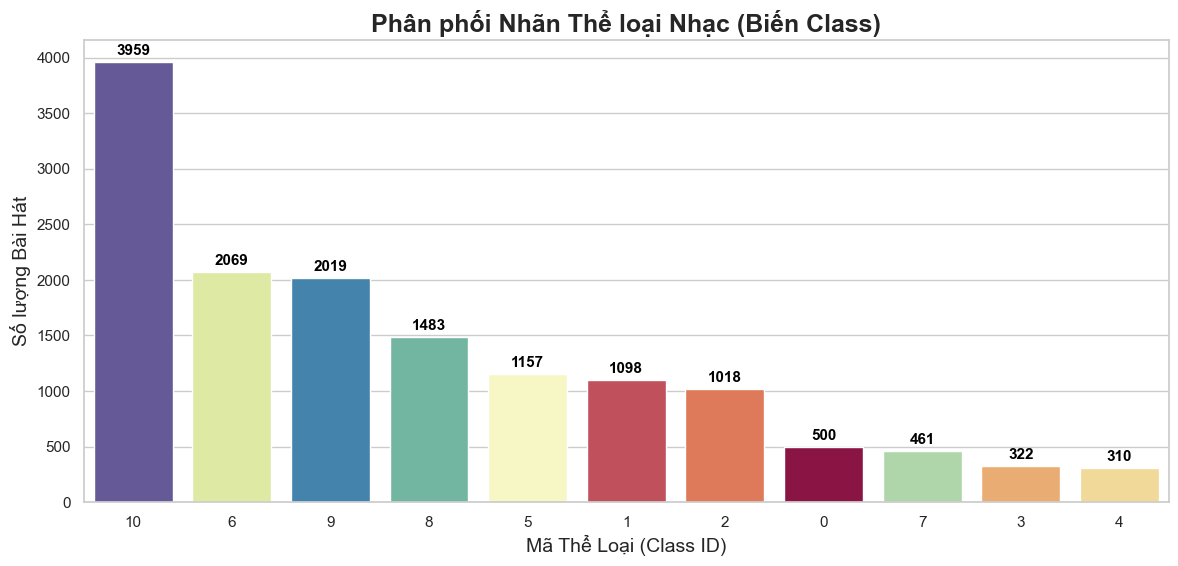

In [6]:
plt.figure(figsize=(14, 6))

# Sắp xếp số lượng từ cao xuống thấp để dễ nhìn
class_order = df['Class'].value_counts().index

# Đã sửa lỗi warning bằng cách thêm hue='Class' và legend=False
ax = sns.countplot(data=df, x='Class', hue='Class', order=class_order, palette='Spectral', legend=False)

plt.title('Phân phối Nhãn Thể loại Nhạc (Biến Class)', fontsize=18, fontweight='bold')
plt.xlabel('Mã Thể Loại (Class ID)', fontsize=14)
plt.ylabel('Số lượng Bài Hát', fontsize=14)

# Thêm nhãn số
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 8), textcoords = 'offset points', 
                fontsize=11, fontweight='bold', color='black')

plt.show()

Quan sát trực quan từ biểu đồ, ta thấy sự mất cân bằng nghiêm trọng Phân phối của 11 thể loại nhạc hoàn toàn không đồng đều:
* *Nhóm Đa số:* Nhãn `10` vươn lên áp đảo hoàn toàn phần còn lại với khoảng hơn 3000 bài hát.
* *Nhóm Trung bình:* Các nhãn `6`, `9`, `8`, `5`, `1`, `2` dao động ở mức từ 1000 đến hơn 2000 bài hát.
* *Nhóm Thiểu số:* Các nhãn `0`, `7`, `3`, `4` có số lượng rất thấp (dưới 500).

Nếu giữ nguyên bộ dữ liệu này đem đi huấn luyện, mô hình sẽ mắc hội chứng "lười biếng" và "thiên vị". Ví dụ, nếu thuật toán cứ "nhắm mắt đoán bừa" mọi bài hát đều thuộc Class `10`, nó vẫn có thể đạt độ chính xác tổng thể lên tới 30-40%. Tuy nhiên, mô hình sẽ hoàn toàn "mù" và bất lực trong việc nhận diện Class `4` hay Class `3`.

---

Để khắc phục vấn đề này, ta có thể áp dụng các chiến lược sau:

**Chiến lược 1: Can thiệp ở cấp độ Dữ liệu (Data-level - Khâu Preprocessing)**
* **KHÔNG dùng Undersampling (Giảm mẫu):** Trừ khi bắt buộc, không nên cắt xén số lượng của Class 10 cho bằng với Class 0. Việc này sẽ làm vứt bỏ đi một lượng khổng lồ thông tin quý giá.
* **Ưu tiên Dùng Oversampling (Tăng mẫu):** Sử dụng kỹ thuật *SMOTE* (Synthetic Minority Over-sampling Technique) hoặc *ADASYN* trên tập huấn luyện. SMOTE sẽ dựa vào thuật toán KNN để nội suy và sinh ra thêm các dữ liệu nhân tạo cho các Class `0, 3, 4, 7` sao cho cân bằng với các Class lớn.
    * *Lưu ý sống còn:* Chỉ áp dụng SMOTE trên tập Train, TUYỆT ĐỐI không áp dụng trên tập Validation/Test để tránh rò rỉ dữ liệu (Data Leakage).

**Chiến lược 2: Can thiệp ở cấp độ Thuật toán (Algorithm-level - Khâu Modeling)**
* **Sử dụng Trọng số Lớp:** Trong các thư viện như Scikit-Learn, khi thiết lập mô hình (như Decision Tree, Random Forest, hay SVM), bắt buộc phải bật tham số `class_weight='balanced'`. Việc này sẽ ép thuật toán "phạt nặng" hơn khi dự đoán sai các nhãn thiểu số (như Class 0) và phạt nhẹ hơn với nhãn đa số (Class 10).
* **Cẩn thận với KNN:** Thuật toán K-Nearest Neighbors rất nhạy cảm với dữ liệu mất cân bằng (vì nó bầu chọn dựa trên số đông hàng xóm xung quanh). Nếu dùng KNN, bắt buộc phải dùng SMOTE trước, hoặc chuyển sang dùng *Distance-weighted KNN* (hàng xóm gần hơn có trọng số bầu lớn hơn).

**Chiến lược 3: Thay đổi Thước đo Đánh giá**
* **Khai tử Metric "Accuracy":** Cấm dùng Accuracy làm tiêu chí đo lường độ tốt của mô hình trong bài toán này.
* **Sử dụng F1-Score & Ma trận Nhầm lẫn:** Bắt buộc dùng *Macro F1-Score* (tính F1 cho từng class rồi chia trung bình cộng) để đảm bảo Class 0 có tiếng nói ngang hàng với Class 10. Ngoài ra, cần vẽ *Confusion Matrix* để xem cụ thể mô hình có đang phân loại nhầm toàn bộ Class 0 thành Class 10 hay không.

## **Phần 3: Trích xuất Đặc trưng Nhiễu / Khuyết**

Trong phần này, chúng ta sẽ định lượng hóa các quan sát từ phần biểu đồ trước bằng các phương pháp thống kê. Trọng tâm sẽ là kiểm tra dữ liệu bị thiếu, phát hiện điểm dị biệt bằng phương pháp IQR (Interquartile Range) và rà soát các lỗi logic dữ liệu.

### **3.1. Báo cáo Dữ liệu Khuyết thiếu**
Đầu tiên, ta sẽ thống kê số lượng và tỷ lệ phần trăm dữ liệu bị khuyết (NaN/Null) trên từng cột.

,Số lượng Missing,Tỷ lệ %
instrumentalness,3541,24.600000
key,1609,11.180000
Popularity,333,2.310000


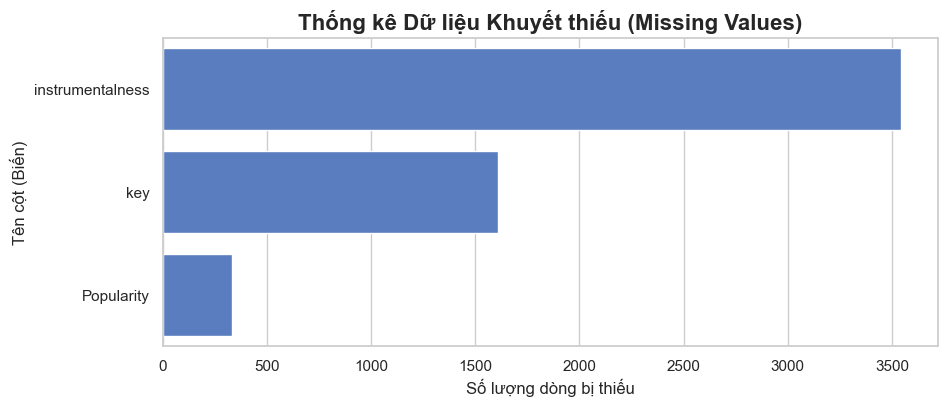

In [7]:
# Tính toán số lượng và tỷ lệ % dữ liệu thiếu
missing_data = df.isnull().sum().to_frame(name='Số lượng Missing')
missing_data['Tỷ lệ %'] = round((missing_data['Số lượng Missing'] / len(df)) * 100, 2)

# Lọc ra chỉ những cột có dữ liệu thiếu và sắp xếp giảm dần
missing_data = missing_data[missing_data['Số lượng Missing'] > 0].sort_values(by='Số lượng Missing', ascending=False)

# Hiển thị bảng báo cáo bằng màu sắc trực quan
display(missing_data.style.background_gradient())

# Vẽ biểu đồ Bar ngang cho Missing Values (nếu có)
if not missing_data.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_data['Số lượng Missing'], y=missing_data.index)
    plt.title('Thống kê Dữ liệu Khuyết thiếu (Missing Values)', fontsize=16, fontweight='bold')
    plt.xlabel('Số lượng dòng bị thiếu')
    plt.ylabel('Tên cột (Biến)')
    plt.show()
else:
    print("Tuyệt vời! Bộ dữ liệu không có giá trị khuyết thiếu nào.")

Dựa trên Biểu đồ Bar chart và Bảng thống kê, bộ dữ liệu hiện có 3 biến bị "lủng lỗ" với mức độ nghiêm trọng chênh lệch rất lớn. Nếu không xử lý đúng kỹ thuật, các giá trị `NaN` này sẽ làm sập toàn bộ luồng huấn luyện thuật toán phía sau.

Dưới đây là bóc tách chi tiết và hướng giải quyết cho từng biến:

**1. Biến `instrumentalness` (Tỷ lệ thiếu: 24.6%)**
* **Nhận diện Vấn đề:** Khuyết tới 3,541 dòng (gần 1/4 tổng dữ liệu). Đây là một tỷ lệ mất mát khổng lồ đối với một đặc trưng âm thanh cốt lõi.
* **Tác hại lên Mô hình:**
    * **Tuyệt đối không được Drop:** Xóa bỏ 3541 dòng sẽ làm mất đi lượng lớn thông tin của các Class khác, gây hao hụt dữ liệu huấn luyện nghiêm trọng.
    * **Nguy cơ sai lệch phân phối:** Ở Phần 2, ta đã biết biến này có phân phối lệch phải cực mạnh (hầu hết giá trị xấp xỉ 0). Nếu điền khuyết toàn bộ 3582 dòng này bằng giá trị Trung bình (Mean), ta sẽ tạo ra một đỉnh giả tạo ở giữa biểu đồ, làm hỏng hoàn toàn "cấu trúc tự nhiên" của nhạc không lời, khiến mô hình phân loại sai các nhãn như Classical hay Jazz.
* **Đề xuất Tiền xử lý (Solutions):**
    * **Ưu tiên 1 (Thuật toán KNN Imputer):** Dùng thuật toán K-Nearest Neighbors để điền khuyết. Thuật toán sẽ xét các bài hát bị thiếu `instrumentalness`, tìm các bài hát có chỉ số `energy`, `loudness`, `acousticness`... giống nó nhất, và lấy giá trị `instrumentalness` của những "hàng xóm" đó điền vào. Cách này giữ nguyên được cấu trúc tương quan của âm thanh.
    * **Ưu tiên 2 (Tạo cờ đánh dấu):** Tạo thêm một cột nhị phân `instrumentalness_is_missing` (1 là khuyết, 0 là không khuyết). Sau đó điền giá trị 0 vào cột gốc. Điều này giúp mô hình nhận biết "bản thân việc bị thiếu dữ liệu cũng là một quy luật".

**3. Biến `key` (Tỷ lệ thiếu: 11.18%)**
* **Nhận diện Vấn đề:** Khuyết 1609 dòng. Đây là biến Phân loại Danh nghĩa với giá trị từ 0 đến 11 đại diện cho các khóa/cung nhạc.
* **Tác hại lên Mô hình:** Lỗi thuật toán cơ bản. Việc điền sai một vài dòng ở biến này hầu như không ảnh hưởng đến độ chính xác tổng thể.
* **Đề xuất Tiền xử lý:** Tuyệt đối không dùng Mean/Median (vì khóa nhạc số 5.5 là vô nghĩa). Hãy điền các ô trống này bằng khóa nhạc xuất hiện nhiều nhất trong tập dữ liệu.

**2. Biến `Popularity` (Tỷ lệ thiếu: 2.31%)**
* **Nhận diện Vấn đề:** Khuyết 333 dòng. Biến này mang tính chất rời rạc (chấm điểm độ phổ biến).
* **Tác hại lên Mô hình:** Khối lượng nhỏ, không làm thay đổi cục diện dữ liệu, nhưng giá trị `NaN` sẽ khiến các mô hình như KNN, SVM, Decision Tree báo lỗi không thể tính toán.
* **Đề xuất Tiền xử lý:**
    * **Dùng Median Imputer (Trung vị):** Không nên dùng Mean (Trung bình) vì biến Popularity có nhiều bài hát cực kỳ nổi tiếng kéo lệch số Mean. Điền bằng Trung vị sẽ an toàn và phản ánh đúng mức độ phổ biến "đại trà" của tập dữ liệu hơn.


### **3.2. Báo cáo Dữ liệu Dị biệt bằng phương pháp IQR**
Ở Phần 2, Boxplot đã cho ta thấy sự tồn tại của Outliers. Bây giờ, ta sẽ dùng phương pháp IQR để đếm chính xác xem mỗi cột có bao nhiêu điểm Outliers.

*IQR (Khoảng tứ phân vị)* là một đại lượng thống kê dùng để đo lường mức độ phân tán của phần trung tâm dữ liệu.

Hãy tưởng tượng bạn xếp tất cả các bài hát theo thứ tự từ âm lượng nhỏ nhất đến lớn nhất, rồi cắt dãy đó ra thành 4 phần bằng nhau (mỗi phần chứa 25% số bài hát). Các nhát cắt đó gọi là các Tứ phân vị:

* Q1 (Percentile 25th): Điểm cắt thứ nhất. 25% dữ liệu nhỏ hơn giá trị này.
* Q2 (Percentile 50th - Median): Trung vị. Điểm chính giữa chia đôi tập dữ liệu.
* Q3 (Percentile 75th): Điểm cắt thứ ba. 75% dữ liệu nhỏ hơn giá trị này.

**Công thức IQR:**
* `IQR = Q3 (Percentile 75th) - Q1 (Percentile 25th)`
* `Cận dưới = Q1 - 1.5 * IQR`
* `Cận trên = Q3 + 1.5 * IQR`
* Mọi giá trị nằm ngoài [Cận dưới, Cận trên] bị coi là Dị biệt về mặt thống kê.

**Tại sao lại dùng IQR để trích xuất Đặc trưng Nhiễu?**

**Lý do 1:** Sự "Kháng nhiễu" tuyệt vời
Giá trị Trung bình (Mean) cực kỳ dễ bị bóp méo bởi outlier.
Ví dụ: Có 5 bài hát dài: 3 phút, 3.5 phút, 4 phút, 3.2 phút và... 1 bài bị lỗi nhập liệu dài tới 300 phút.
Lúc này, Mean sẽ bị kéo vọt lên thành ~62 phút. Nếu dùng Mean để tìm Outlier, bạn sẽ tính sai toàn bộ hệ thống.
Ngược lại, Trung vị (Q2) và IQR hoàn toàn "miễn nhiễm" với các giá trị cực đoan này. Dù bài hát kia có dài 300 hay 3000 phút, cái hộp IQR ở giữa vẫn đứng im không đổi. Do đó, dùng IQR để tìm nhiễu là cách an toàn và bền vững nhất.

**Lý do 2: Không yêu cầu dữ liệu phải có Phân phối Chuẩn**
Phương pháp Z-Score (dùng Độ lệch chuẩn) chỉ hoạt động đúng khi biểu đồ của bạn có hình quả chuông úp ngược hoàn hảo (Phân phối chuẩn - Normal Distribution).
Tuy nhiên, trong bài của chúng ta, các biến như loudness (lệch trái), speechiness và instrumentalness (lệch phải cực đoan). Nếu dùng Z-Score cho các biến này, bạn sẽ nhận được kết quả sai lệch hoàn toàn. IQR không quan tâm dữ liệu của bạn có hình thù gì, nó chỉ đếm vị trí dữ liệu nên nó luôn hoạt động chính xác trên các phân phối lệch (Skewed data).

In [8]:
# Danh sách các biến liên tục cần kiểm tra
numerical_cols = ['danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms']

outlier_report = []

for col in numerical_cols:
    # Bỏ qua các giá trị NaN khi tính toán
    data_col = df[col].dropna()
    
    Q1 = data_col.quantile(0.25)
    Q3 = data_col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Đếm số lượng outliers
    outliers = data_col[(data_col < lower_bound) | (data_col > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = round((outlier_count / len(data_col)) * 100, 2)
    
    outlier_report.append({
        'Biến': col,
        'Số lượng Outlier': outlier_count,
        'Tỷ lệ Outlier (%)': outlier_percent,
        'Cận dưới': lower_bound,
        'Cận trên': upper_bound
    })

# Chuyển thành DataFrame và hiển thị
outlier_df = pd.DataFrame(outlier_report).sort_values(by='Tỷ lệ Outlier (%)', ascending=False)
cm_blue = sns.light_palette("blue", as_cmap=True)
display(outlier_df.set_index('Biến').style.background_gradient(cmap=cm_blue, subset=['Tỷ lệ Outlier (%)']))

,Số lượng Outlier,Tỷ lệ Outlier (%),Cận dưới,Cận trên
Biến,,,,
duration_in min/ms,2583,17.940000,35243.875000,382448.875000
instrumentalness,1940,17.870000,-0.301281,0.502369
speechiness,1633,11.340000,-0.037650,0.155550
liveness,767,5.330000,-0.140813,0.494088
loudness,648,4.500000,-16.102000,1.402000
tempo,32,0.220000,36.515125,205.272125
danceability,29,0.200000,0.093000,0.997000
energy,0,0.000000,-0.021500,1.390500
acousticness,0,0.000000,-0.637675,1.074205


Trong đoạn code phát hiện dị biệt phía trên, thuật toán IQR chỉ được áp dụng cho danh sách `numerical_cols` (gồm 10 biến định lượng liên tục). Việc chủ ý loại bỏ các biến Danh nghĩa, Rời rạc và Văn bản dựa trên các nguyên tắc thống kê sau:

**1. Rào cản về Khoảng cách Đại số đối với Biến Danh nghĩa (`key`, `mode`, `Class`):**
* Phương pháp IQR định nghĩa Outlier là các điểm nằm cách xa vùng trung tâm một khoảng `1.5 * IQR`. Việc này yêu cầu dữ liệu phải có tính liên tục và tính toán được khoảng cách.
* Đối với biến như `key` (Khóa nhạc 0-11), mặc dù được mã hóa bằng số, nhưng về mặt đại số, khóa B (11) không hề "dị biệt" hay có khoảng cách xa 10 đơn vị so với khóa C# (1). Nếu ép máy tính chạy IQR, nó sẽ tính ra các ranh giới vô nghĩa.
* *Cách bắt lỗi đúng:* Dị biệt của biến danh nghĩa là "sự khan hiếm". Ta đã dùng Countplot ở Phần 2 để kiểm tra xem có khóa nhạc nào xuất hiện quá ít hay không.

**2. Lỗi "Low Variance" (Độ phân tán thấp) đối với Biến Rời rạc (`time_signature`):**
* Biến `time_signature` (Số nhịp) có hơn 90% bài hát mang giá trị 4 (nhịp 4/4). 
* Nếu áp dụng IQR, ta sẽ có: $Q_1 = 4$, $Q_3 = 4$ $\rightarrow$ $IQR = 0$. Cận trên và Cận dưới đều bằng 4.
* Lúc này, thuật toán IQR sẽ cực đoan đánh dấu *mọi bài hát* có nhịp 3/4 (Valse) hay 5/4 là dữ liệu lỗi. Điều này là sai hoàn toàn về mặt logic âm nhạc học.

**3. Không thể thực hiện phép tính với Biến Văn bản (`Id`, `Artist Name`):**
* Dữ liệu dạng chuỗi không thể sắp xếp để tìm Tứ phân vị hay thực hiện các phép trừ toán học ($Q_3 - Q_1$).

Bảng thống kê tỷ lệ Outlier dựa trên phương pháp IQR đã lượng hóa chính xác mức độ phân tán của 10 biến liên tục. Dựa vào tỷ lệ phần trăm và đặc thù của ngành âm thanh, chúng ta có thể chia các biến này thành 3 nhóm hành động như sau:

**Nhóm 1: Tỷ lệ Outlier Cao & Mang tính Đặc trưng (Tỷ lệ > 10%)**
**Gồm các biến:** `duration_in min/ms` (17.94%), `instrumentalness` (17.87%), `speechiness` (11.34%).
* **`duration_in min/ms` (17.94%):** Con số khổng lồ này chính là bằng chứng thép cho *Lỗi trộn lẫn đơn vị đo* mà ta đã phát hiện ở mục 3.3. Những bài hát bị nhập bằng "Phút" (ví dụ: 3.5, 4.2) nằm lọt thỏm ở sát mốc 0, khiến hệ thống hiểu nhầm chúng là Outlier. 

  $\rightarrow$ **Hướng xử lý:** Bắt buộc phải nhân các giá trị nhỏ hơn 100 với 60,000 để đưa về mili-giây.
* **`instrumentalness` và `speechiness`:** Tỷ lệ Outlier lớn (17.87% và 11.34%) xuất phát từ hiện tượng *Dồn ứ tại 0 (Zero-inflated)*. Do đại đa số nhạc đại chúng là nhạc có lời (hát), cái "Hộp" IQR của chúng ta bị bóp nghẹt lại ở sát mốc 0 (Cận trên của hai biến này chỉ lần lượt là 0.134 và 0.128). Do đó, bất kỳ bản nhạc Giao hưởng (không lời) hay Rap (đọc dồn dập) nào vượt qua Cận trên này đều bị gắn cờ dị biệt.

  $\rightarrow$ **Hướng xử lý:** TUYỆT ĐỐI KHÔNG XÓA HOẶC GIỚI HẠN. Đây chính là "ADN nhận diện" của các thể loại ngách. Đối với mô hình Naive Bayes, cân nhắc dùng phép biến đổi Logarit: $Log(x+1)$.

**Nhóm 2: Tỷ lệ Outlier Trung bình & Phụ thuộc Ngữ cảnh (Tỷ lệ 4% - 6%)**
**Gồm các biến:** `liveness` (5.33%), `loudness`(4.5%).
Nhóm này phản ánh đúng sự biến thiên tự nhiên của môi trường thu âm và kỹ thuật hòa âm.
* **`liveness` (Hát Live):** 5.33% bài hát vượt Cận trên (0.36) chính là các bản thu trực tiếp từ Concert hoặc Live Show, nơi có lẫn tiếng ồn của khán giả. 
* **`loudness` (Âm lượng):** 4.5% bài hát bị rớt xuống dưới Cận dưới (-14.86 dB). Trong bối cảnh "Loudness War" (nhạc Pop/EDM bị nén cho cực to), những điểm rớt đài này chính là các bản nhạc Acoustic, Folk, hoặc Classical - những thể loại tôn trọng khoảng lặng và dải động học chân thực.
  $\rightarrow$ **Hướng xử lý:** Giữ nguyên trạng. Đối với `loudness`, bắt buộc dùng StandardScaler để đưa dải âm sâu này về cùng hệ quy chiếu với các biến [0, 1] trước khi chạy KNN.

**Nhóm 3: Dữ liệu Sạch / Ít Outlier (Tỷ lệ < 1%)**
**Gồm các biến:** `tempo` (0.22%), `danceability` (0.2%), `acousticness` (0%), `valence` (0%), `energy` (0%).
* **Nhận định:** Đây là các biến "vàng" của bộ dữ liệu. Phân phối của chúng trải đều đặn đặn trên dải đo (như `valence` hay `acousticness`) nên hộp IQR đủ rộng để bao trọn 100% dữ liệu. Chỉ có vài ca cực hiếm ở `tempo` (nhịp quá nhanh/chậm) và `danceability` (hoàn toàn không có nhịp điệu).
  $\rightarrow$ **Hướng xử lý:** Dữ liệu đã sẵn sàng để đưa vào mọi mô hình. Chỉ cần Scale cột `tempo` do có thang đo thực tế lớn (BPM).

### **3.3. Rà soát Lỗi Logic Dữ liệu**
Cuối cùng, ta viết các query để tìm ra những điểm vô lý trong logic vật lý của âm thanh.

In [9]:
print("BÁO CÁO CÁC LỖI LOGIC VÀ BẤT THƯỜNG DỮ LIỆU:")
print("-" * 50)

# 1. Kiểm tra Tempo = 0 (BPM bằng 0 là một điều vô lý đối với 1 bài hát bình thường)
tempo_zero = df[df['tempo'] == 0].shape[0]
print(f"1. Số bài hát có tempo = 0 BPM: {tempo_zero} bài.")

# 2. Kiểm tra lỗi trộn lẫn đơn vị trong cột 'duration_in min/ms'
# Giả sử một bài hát cực ngắn cũng phải > 0.5 phút. Những giá trị < 100 khả năng cao là đơn vị Phút, trong khi hàng trăm ngàn là mili-giây.
duration_mins = df[df['duration_in min/ms'] < 100].shape[0]
print(f"2. Số bài hát có thời lượng bị nhập theo đơn vị Phút (< 100): {duration_mins} bài (Cần quy đổi sang ms).")

# 3. Kiểm tra biến Popularity = 0
pop_zero = df[df['Popularity'] == 0].shape[0]
print(f"3. Số bài hát có Popularity bị gán bằng 0: {pop_zero} bài.")

# 4. Kiểm tra sự dồn ứ (Zero-inflated) ở instrumentalness
instru_zero = df[df['instrumentalness'] < 0.001].shape[0]
print(f"4. Số bài hát gần như có lời hoàn toàn (instrumentalness < 0.001): {instru_zero} bài ({round((instru_zero/len(df))*100, 2)}%).")

BÁO CÁO CÁC LỖI LOGIC VÀ BẤT THƯỜNG DỮ LIỆU:
--------------------------------------------------
1. Số bài hát có tempo = 0 BPM: 0 bài.
2. Số bài hát có thời lượng bị nhập theo đơn vị Phút (< 100): 2075 bài (Cần quy đổi sang ms).
3. Số bài hát có Popularity bị gán bằng 0: 0 bài.
4. Số bài hát gần như có lời hoàn toàn (instrumentalness < 0.001): 4472 bài (31.06%).


Dựa trên kết quả truy vấn các quy luật vật lý và logic của âm thanh, chúng ta thu được 4 kết luận cực kỳ đắt giá sau:
**1. Biến `tempo` và `Popularity` rất sạch sẽ**
* **Thống kê:** Có 0 bài hát có `tempo = 0` và 0 bài hát có `Popularity = 0`.
* **Phân tích:** Đây là một tin rất đáng mừng. 
    * Một bài hát không thể có nhịp độ bằng 0 (trừ khi nó là một khoảng lặng). Việc không có giá trị 0 chứng tỏ cột `tempo` không bị khuyết ngầm.
    * Tương tự, cột `Popularity` không bị gán "chữa cháy" bằng 0 bởi hệ thống thu thập dữ liệu. Chúng ta không cần lo lắng về lỗi logic ở hai biến này.

**2. Biến `duration_in min/ms` có LỖI TRỘN LẪN ĐƠN VỊ NGHIÊM TRỌNG**
* **Thống kê:** Có tới *2,075 bài hát* (chiếm khoảng ~14% tập dữ liệu) có thời lượng nhỏ hơn 100.
* **Phân tích Tác hại:** Đây là lỗi *Trộn lẫn đơn vị đo* kinh điển do quá trình thu thập dữ liệu từ nhiều nguồn khác nhau (ví dụ: Spotify API dùng mili-giây, trong khi một nguồn khác lại dùng phút).
    * Một bài hát dài 3.5 phút đang được ghi là `3.5`.
    * Một bài hát 3.5 phút khác lại được ghi chuẩn là `210000` (mili-giây).
    * Nếu đưa thẳng vào mô hình (đặc biệt là KNN), thuật toán sẽ coi bài `3.5` và bài `210000` là hai thể loại hoàn toàn khác biệt nhau cực kỳ xa, làm hỏng hoàn toàn sức mạnh dự đoán của biến thời lượng.
* **Đề xuất Tiền xử lý:** Khi Preprocessing *bắt buộc* phải viết một hàm Lambda biến đổi: 
  `df['duration_ms'] = df['duration_in min/ms'].apply(lambda x: x * 60000 if x < 100 else x)`
  Sau khi đồng nhất về mili-giây, ta mới có thể chạy `StandardScaler` một cách an toàn.

**3. Biến `instrumentalness` có đặc trưng hội tụ** 
* **Thống kê:** Có *4,472 bài hát (31.06%)* mang giá trị `instrumentalness < 0.001` (gần như bằng 0).
* **Phân tích Thống kê & Âm nhạc học:**
     * Con số này tái khẳng định quan sát từ biểu đồ Histogram ở Phần 2. Hơn 31% bộ dữ liệu là các bài hát mang đậm yếu tố thanh nhạc (Vocal-heavy) như Pop, Rap, R&B, nơi giọng hát lấn át hoàn toàn nhạc cụ.
    * Đây không phải là lỗi, mà là bản chất tự nhiên của ngành công nghiệp âm nhạc đại chúng.
* **Tác động tới Modeling:**
    * Sự dồn ứ (Zero-inflated) tại mốc 0 sẽ vi phạm giả định "Phân phối chuẩn" của mô hình *Gaussian Naive Bayes*. 
    * **Đề xuất Tiền xử lý:** Có thể thử nghiệm tạo ra một biến Feature Engineering mới: Biến phân loại nhị phân `is_vocal` (Giá trị = 1 nếu `instrumentalness < 0.001`, ngược lại = 0). Mô hình Cây quyết định sẽ học phân nhánh rất tốt trên biến nhị phân này để tách biệt ngay lập tức nhóm nhạc có lời và không lời.

## **Phần 4: Đề xuất Hướng giải quyết và Tiền xử lý**

Từ những phân tích chuyên sâu về phân phối, nhiễu và lỗi logic ở các phần trước, tôi đề xuất một quy trình tiền xử lý dữ liệu nghiêm ngặt gồm 4 bước chính nhằm tối ưu hóa hiệu suất cho các mô hình KNN, Naive Bayes và Decision Tree.

### **4.1. Xử lý Lỗi Logic & Làm sạch Dữ liệu**

Đây là bước bắt buộc phải thực hiện đầu tiên trước khi tính toán bất kỳ chỉ số thống kê nào:

**1.  Đồng nhất đơn vị Thời lượng (`duration_in min/ms`):**
    * *Vấn đề:* Trộn lẫn Phút và Mili-giây.
    * *Giải pháp:* Áp dụng quy tắc quy đổi: Nếu giá trị < 100, nhân với 60,000.
    * *Code gợi ý:* `df['duration'] = df['duration_in min/ms'].apply(lambda x: x * 60000 if x < 100 else x)`

**2.  Xử lý giá trị bằng 0 bất thường:**
    * Nếu có `tempo = 0` phát sinh sau này, cần coi đó là dữ liệu khuyết và điền bằng Median của Class đó.

### **4.2. Chiến lược Điền khuyết Phân tầng**

Tuyệt đối không sử dụng một phương pháp điền khuyết chung cho toàn bộ bảng. Đề xuất:

* **Đối với `instrumentalness` (Thiếu 24.6%):** Sử dụng *KNN Imputer* (với k=5) dựa trên các đặc trưng `energy`, `acousticness` và `loudness` để dự đoán giá trị thiếu. Việc này giúp giữ được bản chất của nhạc không lời.
* **Đối với `key` (Thiếu 11.18%):** Sử dụng *SimpleImputer* với chiến lược most_frequent (Mode).
* **Đối với `Popularity` (Thiếu 2.31%):** Sử dụng *SimpleImputer* với chiến lược median.


### **4.3. Mã hóa & Chuẩn hóa Đặc trưng**

Tùy vào bản chất đại số đã phân loại ở Phần 1, các biến cần được xử lý như sau:

| Nhóm biến | Danh sách cột | Kỹ thuật đề xuất | Lý do |
| :--- | :--- | :--- | :--- |
| **Định danh** | `key` | **One-Hot Encoding** | Tránh mô hình hiểu lầm khóa 11 lớn hơn khóa 1. |
| **Nhị phân** | `mode` | Giữ nguyên (0/1) | Đã ở định dạng chuẩn cho máy học. |
| **Thang đo lớn** | `loudness`, `tempo`, `duration`, `Popularity` | **StandardScaler** | Đưa về trung bình 0, phương sai 1 để không lấn át các biến [0,1] trong KNN. |
| **Phân phối lệch** | `speechiness`, `liveness`, `instrumentalness` | **Log Transformation** | Giảm độ lệch phải (Right-skewed) giúp Naive Bayes hoạt động tốt hơn. |
| **Loại bỏ** | `Id`, `Artist Name`, `Track Name` | **Drop** | Tránh nhiễu văn bản và hiện tượng Overfitting (học vẹt tên ca sĩ). |

### **4.4. Kỹ thuật Đặc trưng Mới**

Để hỗ trợ mô hình nhận diện thể loại tốt hơn, tôi đề xuất tạo thêm các biến phái sinh:
1.  **`is_vocal` (Biến cờ):** Giá trị = 1 nếu `instrumentalness < 0.001`, ngược lại = 0. Giúp tách biệt nhóm Pop/Rap và nhóm Classical.
2.  **`energy_loudness_ratio`:** Tỷ lệ giữa năng lượng và âm lượng, có thể giúp phân biệt Rock (cả hai đều cao) và EDM (năng lượng cao nhưng âm lượng được nén khác).

### **4.5. Chiến lược Huấn luyện & Đánh giá**

Cuối cùng, để giải quyết vấn đề *Mất cân bằng dữ liệu nghiêm trọng* của biến mục tiêu `Class` (Class 10 quá nhiều, Class 0 quá ít):

1.  **Cân bằng dữ liệu:** * Sử dụng kỹ thuật *SMOTE* trên tập huấn luyện để nhân bản dữ liệu cho các Class thiểu số (0, 3, 5).
    * Hoặc thiết lập tham số `class_weight='balanced'` trong các mô hình Decision Tree / Random Forest.
2.  **Lựa chọn mô hình:**
    * **KNN:** Bắt buộc phải thực hiện Scaling (Bước 4.3) trước khi chạy.
    * **Naive Bayes:** Ưu tiên dùng *GaussianNB* cho các biến liên tục và *CategoricalNB* cho các biến đã One-hot.
3.  **Tiêu chí đánh giá:**
    * KHÔNG sử dụng Accuracy.
    * Sử dụng *Macro F1-Score* và *Confusion Matrix* để đảm bảo mô hình nhận diện đúng các thể loại nhạc hiếm.

## **Phần 5: Giả thuyết Ánh xạ Thể loại Âm nhạc**

Dựa trên kết quả Phân tích Đơn biến (Phần 2) và Truy xuất Nhiễu/Khuyết (Phần 3), kết hợp với kiến thức chuyên ngành về cấu trúc âm thanh, tôi đưa ra các giả thuyết dự đoán tên Thể loại Nhạc cho 11 nhãn của biến `Class`:

| Mã Class | Tần suất | Giả thuyết Thể loại | Luận điểm từ Dữ liệu |
| :---: | :---: | :--- | :--- |
| **10** | Áp đảo | **Rock / Metal / Punk** | Mức độ phổ biến cao nhất. Hội tụ các bài có `energy` cao, `loudness` cực lớn. Phân phối `instrumentalness` thấp (có người hát/gào). |
| **6** | Trung bình | **Hip-Hop / Rap** | Đặc trưng độc nhất là nằm trong nhóm có Outlier của cột `speechiness` cực kỳ cao (>0.3). Nhịp điệu (`danceability`) rất tốt. |
| **5** | Thấp | **EDM / Electronic / Dance** | Đỉnh phân phối `tempo` hội tụ cực mạnh ở dải 120-130 BPM (nhịp điệu tiêu chuẩn của nhạc sàn). Năng lượng cao, thỉnh thoảng có Outlier ở `instrumentalness` (các đoạn drop không lời). |
| **8 & 9** | Trung bình | **Pop / Latin / Reggae** | Các chỉ số cực kỳ "đẹp" và cân bằng. `Valence` (độ tích cực) trải dài và thường ở mức cao (nhạc vui tươi). Điểm `Popularity` cao. |
| **0 & 3** | Rất hiếm | **Classical (Cổ điển) / Symphony** | Góp phần tạo ra dải Outlier âm sâu của `loudness` (âm lượng rất nhỏ ở những đoạn lặng). Cột `instrumentalness` gần như bằng 1 (hoàn toàn không có lời). |
| **7** | Hiếm | **Jazz / Blues** | Có sự biến thiên lớn về `time_signature` (nhịp bất đối xứng) và `acousticness` cao do dùng nhạc cụ mộc (Saxophone, Piano). |
| **4** | Hiếm | **Country / Live Folk** | Sự xuất hiện của các Outlier ở biến `liveness` cho thấy có nhiều bài hát được thu âm trực tiếp (Live Acoustic/Concert) thay vì ở Studio. Cột `acousticness` khá cao. |


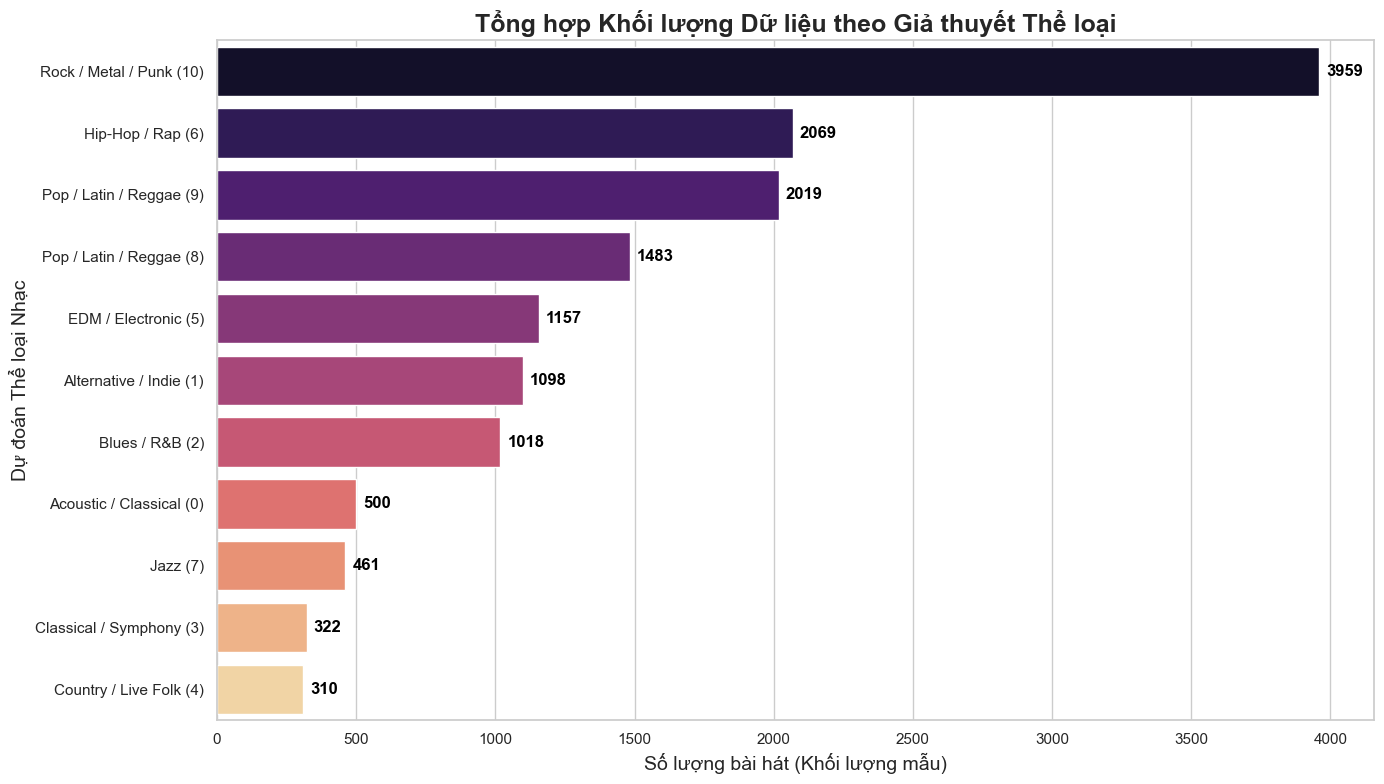

In [10]:
# 1. Tạo từ điển ánh xạ (Mapping Dictionary) từ mã Class sang Tên Thể loại dựa trên giả thuyết
genre_mapping = {
    10: 'Rock / Metal / Punk (10)',
    9: 'Pop / Latin / Reggae (9)',
    8: 'Pop / Latin / Reggae (8)',
    6: 'Hip-Hop / Rap (6)',
    2: 'Blues / R&B (2)',
    1: 'Alternative / Indie (1)',
    7: 'Jazz (7)',
    5: 'EDM / Electronic (5)',
    4: 'Country / Live Folk (4)',
    3: 'Classical / Symphony (3)',
    0: 'Acoustic / Classical (0)'
}

# 2. Tạo một cột tạm thời để lưu tên thể loại
df['Predicted_Genre'] = df['Class'].map(genre_mapping)

# 3. Tính toán số lượng cho từng thể loại và sắp xếp giảm dần
genre_counts = df['Predicted_Genre'].value_counts().reset_index()
genre_counts.columns = ['Thể loại (Genre)', 'Số lượng']

# 4. Vẽ biểu đồ Bar ngang (Horizontal Bar Chart)
plt.figure(figsize=(14, 8))
# Sử dụng hue và legend=False để tránh warning của Seaborn phiên bản mới
ax = sns.barplot(data=genre_counts, x='Số lượng', y='Thể loại (Genre)', 
                 hue='Thể loại (Genre)', palette='magma', legend=False)

plt.title('Tổng hợp Khối lượng Dữ liệu theo Giả thuyết Thể loại', fontsize=18, fontweight='bold')
plt.xlabel('Số lượng bài hát (Khối lượng mẫu)', fontsize=14)
plt.ylabel('Dự đoán Thể loại Nhạc', fontsize=14)

# Thêm nhãn số lượng chi tiết ở đuôi mỗi cột
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# Xóa cột tạm để không ảnh hưởng đến dữ liệu gốc của team Preprocessing
df.drop(columns=['Predicted_Genre'], inplace=True)

Nhìn vào biểu đồ này, bức tranh toàn cảnh về *Sự vắng mặt của các Nhóm Ngách* hiện lên cực kỳ rõ nét:
* Mô hình của chúng ta sẽ học rất nhanh cách phân biệt `Rock` (rất ồn), `Hip-Hop` (rất nhiều lời) và `Pop` (phổ biến) vì chúng thống trị kho dữ liệu.
* Tuy nhiên, các thể loại mang giá trị nghệ thuật cao và có đặc trưng âm thanh độc đáo như `Classical / Symphony`, `Country` hay `Jazz` lại nằm chót bảng với số lượng đếm trên đầu ngón tay. 

In [11]:
# Cấu trúc lưu ảnh hoặc file csv hoặc dữ liệu nào cần thiết
# Đây là cấu trúc lưu file csv, nhưng hầu như công đoạn này lưu ảnh
# --> dùng AI để sửa lại cho đúng ảnh mún lưu

now = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"{now}_data_univariateAnalysis.csv"
filepath = os.path.join("..", "Notebooks", "EDA", "UnivariateAnalysis", filename)
os.makedirs(os.path.dirname(filepath), exist_ok=True)

df.to_csv(filepath, index=False)

print("Saved:", filepath)

Saved: ..\Notebooks\EDA\UnivariateAnalysis\20260515_094428_data_univariateAnalysis.csv
